# README

This notebook contains analysis for different local LLMs each beoing prompted with the task generating an emails with different output length requirements.

## Links

repo: https://github.com/envite-consulting/ollama-llm-energy-measurement/tree/main

OpenAPI GMT: https://api.green-coding.io/docs#/

<hr>

## TODO

- [ ] import runs from GMT

- [ ] add interactive element to select run_ids

# Notebook

## Imports

In [376]:
import requests
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML
import numpy as np
import re
import ipywidgets as widgets

## Input Parameters

In [377]:
REPOSITORY = 'https://github.com/envite-consulting/ollama-llm-energy-measurement'

In [378]:
# Add .api-key in root of repo with GMT-Api-Key
with open('../.api-key', 'r') as f:
    API_KEY = f.read().strip()

## Getting Run_IDs

In [379]:
def get_run_ids():
    url = "https://api.green-coding.io/v2/runs"  # Replace with the actual endpoint from the OpenAPI spec
    headers = {
        "x-authentication": API_KEY
    }
    params = {
        "uri": REPOSITORY
    }

    response = requests.get(url, headers=headers, params=params)
    # Print the status of the request and the number of runs
    print(f"Request Status: {response.status_code} {response.reason}")
    response_json = response.json()
    print(f"Number of Runs: {len(response_json.get('data', []))}")
    return response

response = get_run_ids()

Request Status: 200 OK
Number of Runs: 20


### Saving in Dataframe

In [380]:
def display_gmt_data_as_dataframe(response):
    # Extract the 'data' property from the response
    data = response.json().get('data', [])

    # Create a DataFrame with the first 7 entries of each row
    df = pd.DataFrame(data, columns=['Run_ID', 'Name', 'Repo', 'Branch', 'Time', 'unknown', 'Usage_Scenario'] + [f'Extra_{i}' for i in range(len(data[0]) - 7)])
    df = df[['Run_ID', 'Name', 'Repo', 'Branch', 'Time', 'Usage_Scenario']]  # Keep only the required columns, excluding 'unknown'

    return df

gmt_dataframe = display_gmt_data_as_dataframe(response)

# Uncomment to see the dataframe
gmt_dataframe

,Run_ID,Name,Repo,Branch,Time,Usage_Scenario
0,72fe8e85-e503-4756-a840-41889e561288,EMail Ollama Measurement Deepseek 1.5B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T16:25:34.204084+02:00,usage_scenario_email_deepseekr1_1_5b.yml
1,e14e9506-75ce-4a10-bc5a-e0a87748d702,EMail Ollama Measurement Deepseek 1.5B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T16:16:35.031520+02:00,usage_scenario_email_deepseekr1_1_5b.yml
2,bd9415bf-9664-4ad5-b739-b593e7d3ff8d,EMail Ollama Measurement Deepseek 1.5B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T16:08:34.851600+02:00,usage_scenario_email_deepseekr1_1_5b.yml
3,099086d9-793e-437d-86a0-e113679ec78e,EMail Ollama Measurement Llama 3.2 3B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T15:59:36.678543+02:00,usage_scenario_email_llama32_3b.yml
4,d10d0b34-18b1-47c0-b2e8-1ffd52aea9c8,EMail Ollama Measurement Llama 3.2 3B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T15:50:47.698796+02:00,usage_scenario_email_llama32_3b.yml
5,a0253185-b2bb-4b4e-8fee-cb0894536646,EMail Ollama Measurement Llama 3.2 3B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T15:42:00.154661+02:00,usage_scenario_email_llama32_3b.yml
6,f751405c-a81a-4642-b8a4-321c135d8331,EMail Ollama Measurement Llama 3.2 1B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T15:34:38.301686+02:00,usage_scenario_email_llama32_1b.yml
7,bc6e44f4-9e65-49dc-8ce7-50b22c95b796,EMail Ollama Measurement Llama 3.2 1B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T15:27:16.846380+02:00,usage_scenario_email_llama32_1b.yml
8,f4bc5ea5-3a8e-4ee0-920b-d65c79e56e11,EMail Ollama Measurement Llama 3.2 1B,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T15:19:55.832297+02:00,usage_scenario_email_llama32_1b.yml
9,d5c758ac-89dd-497f-822a-f76b65984e39,EMail Ollama Measurement Gemma 3 4b,https://github.com/envite-consulting/ollama-ll...,emailmeasurement,2025-06-27T12:53:01.361964+02:00,usage_scenario_email_gemma3_4b.yml


## Select Runs

In [381]:
# this is hardcoded for now, a select element should be added later

# hard-coding Gemma3 4B runs for now
selected_ids = [
    'd5c758ac-89dd-497f-822a-f76b65984e39',
    '75299ba8-6109-4c90-9c7f-352cc9c4d870',
    'e7fdc1bc-02b9-435e-8dce-e9685b08d88a'
]

# Additional variables for other run groups (example: adjust 'Name' values as needed)
deepseek_1_5b_ids = gmt_dataframe[gmt_dataframe['Name'].str.contains('EMail Ollama Measurement Deepseek 1.5B', case=False, na=False)]['Run_ID'].tolist()[:3]
gemm3_4b_ids = gmt_dataframe[gmt_dataframe['Name'].str.contains('EMail Ollama Measurement Gemma 3 4b', case=False, na=False)]['Run_ID'].tolist()[:3]
gemm3_1b_ids = gmt_dataframe[gmt_dataframe['Name'].str.contains('EMail Ollama Measurement Gemma3 1b', case=False, na=False)]['Run_ID'].tolist()[:3]
llama32_3b_ids = gmt_dataframe[gmt_dataframe['Name'].str.contains('EMail Ollama Measurement Llama 3.2 3B', case=False, na=False)]['Run_ID'].tolist()[:3]
llama32_1b_ids = gmt_dataframe[gmt_dataframe['Name'].str.contains('EMail Ollama Measurement Llama 3.2 1B', case=False, na=False)]['Run_ID'].tolist()[:3]


# Example usage:
print("Deepseek 1.5B IDs:", deepseek_1_5b_ids)
print("Gemma 3 4b IDs:", gemm3_4b_ids)
print("Gemma3 1b IDs:", gemm3_1b_ids)
print("Llama 3.2 3B IDs:", llama32_3b_ids)
print("Llama 3.2 1B IDs:", llama32_1b_ids)


# Fetch phase_stats for all gemm3_4b_ids and build phase_dataframes for each
all_phase_dataframes = []
for run_id in gemm3_4b_ids:
    phase_stats = fetch_phase_stats(run_id)
    phase_dataframes = {}
    for phase, measurements in phase_stats.items():
        rows = []
        for measurement_name, measurement_details in measurements.items():
            if 'data' in measurement_details:
                for component_name, component_details in measurement_details['data'].items():
                    for run_id_inner, run_data in component_details['data'].items():
                        rows.append({
                            'Name': measurement_name,
                            'Component': component_name,
                            'Type': measurement_details['type'],
                            'Unit': measurement_details['unit'],
                            'Value': run_data['mean']
                        })
        phase_dataframes[phase] = pd.DataFrame(rows)
    all_phase_dataframes.append(phase_dataframes)

def merge_phase_dataframes(phase_dataframes_list):
    merged = {}
    for phase_dataframes in phase_dataframes_list:
        for phase, df in phase_dataframes.items():
            if phase not in merged:
                merged[phase] = df.copy()
            else:
                merged[phase] = pd.concat([merged[phase], df], ignore_index=True)
    # Now group and average Value for identical rows
    for phase in merged:
        if not merged[phase].empty:
            merged[phase] = (
                merged[phase]
                .groupby(['Name', 'Component', 'Type', 'Unit'], as_index=False)
                .agg({'Value': lambda x: np.median(x.astype(float))})
            )
    return merged

# Merge all phase_dataframes into one, averaging Value for identical rows
phase_dataframes_all = merge_phase_dataframes(all_phase_dataframes)
phase_dataframes_all['[BASELINE]']

Deepseek 1.5B IDs: ['72fe8e85-e503-4756-a840-41889e561288', 'e14e9506-75ce-4a10-bc5a-e0a87748d702', 'bd9415bf-9664-4ad5-b739-b593e7d3ff8d']
Gemma 3 4b IDs: ['d5c758ac-89dd-497f-822a-f76b65984e39', '75299ba8-6109-4c90-9c7f-352cc9c4d870', 'e7fdc1bc-02b9-435e-8dce-e9685b08d88a']
Gemma3 1b IDs: ['fedc81ad-3caa-4ec6-9c3f-efbc0539f47c', '38087ab2-6f89-4e14-94f3-7771f5e1c4eb', '4c084331-6356-49ca-99e8-490ac62b7733']
Llama 3.2 3B IDs: ['099086d9-793e-437d-86a0-e113679ec78e', 'd10d0b34-18b1-47c0-b2e8-1ffd52aea9c8', 'a0253185-b2bb-4b4e-8fee-cb0894536646']
Llama 3.2 1B IDs: ['f751405c-a81a-4642-b8a4-321c135d8331', 'bc6e44f4-9e65-49dc-8ce7-50b22c95b796', 'f4bc5ea5-3a8e-4ee0-920b-d65c79e56e11']


,Name,Component,Type,Unit,Value
0,cpu_energy_rapl_msr_component,Package_0,TOTAL,uJ,5.043730e+08
1,cpu_power_rapl_msr_component,Package_0,MEAN,mW,8.384000e+03
2,cpu_utilization_cgroup_system,GMT Overhead,MEAN,Ratio,5.400000e+01
3,cpu_utilization_procfs_system,[SYSTEM],MEAN,Ratio,5.600000e+01
4,embodied_carbon_share_machine,[SYSTEM],TOTAL,ug,8.632100e+04
5,gpu_energy_nvidia_nvml_component,NVIDIA GeForce GTX 1080-0,TOTAL,uJ,1.084202e+09
6,gpu_power_nvidia_nvml_component,NVIDIA GeForce GTX 1080-0,MEAN,mW,1.802200e+04
7,lmsensors_temperature_component,coretemp-isa-0000_Core-0,MEAN,centi°C,3.996000e+03
8,lmsensors_temperature_component,coretemp-isa-0000_Package-id-0,MEAN,centi°C,3.996000e+03
9,memory_energy_rapl_msr_component,DRAM_0,TOTAL,uJ,4.083153e+07


### Fetch Measurement Data for Runs

In [382]:
def fetch_measurement_data(run_id):
    url = f"https://api.green-coding.io/v1/measurements/single/{run_id}"
    headers = {
        "x-authentication": API_KEY
    }
    response = requests.get(url, headers=headers)
    return response.json()

# Fetch data for each selected Run_ID
    measurement_data = fetch_measurement_data(selected_id)[data]
   

### Fetch Measurement Data for Phases

In [383]:
def fetch_phase_stats(selected_id):
    url = f"https://api.green-coding.io/v1/phase_stats/single/{selected_id}"
    headers = {
        "x-authentication": API_KEY
    }
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json().get('data', {}).get('data', {})
    else:
        print(f"Failed to fetch phase stats for Run ID {selected_id}: {response.status_code} {response.reason}")
        return null


# Example usage
#phase_stats = fetch_phase_stats(selected_id)
phase_stats_all = phase_dataframes_all  # Use the merged phase dataframes instead of fetching again
phase_stats_all['[BASELINE]']

,Name,Component,Type,Unit,Value
0,cpu_energy_rapl_msr_component,Package_0,TOTAL,uJ,5.043730e+08
1,cpu_power_rapl_msr_component,Package_0,MEAN,mW,8.384000e+03
2,cpu_utilization_cgroup_system,GMT Overhead,MEAN,Ratio,5.400000e+01
3,cpu_utilization_procfs_system,[SYSTEM],MEAN,Ratio,5.600000e+01
4,embodied_carbon_share_machine,[SYSTEM],TOTAL,ug,8.632100e+04
5,gpu_energy_nvidia_nvml_component,NVIDIA GeForce GTX 1080-0,TOTAL,uJ,1.084202e+09
6,gpu_power_nvidia_nvml_component,NVIDIA GeForce GTX 1080-0,MEAN,mW,1.802200e+04
7,lmsensors_temperature_component,coretemp-isa-0000_Core-0,MEAN,centi°C,3.996000e+03
8,lmsensors_temperature_component,coretemp-isa-0000_Package-id-0,MEAN,centi°C,3.996000e+03
9,memory_energy_rapl_msr_component,DRAM_0,TOTAL,uJ,4.083153e+07


> create a dataframe for each phase in phase_stats giving an overview of the contained measurements. include the name, the type, the unit  and the value of the mesaurement

In [384]:
# Adjusting the code to handle the structure of phase_stats correctly

phase_dataframes = {}

for phase, measurements in phase_stats_all.items():
    rows = []
    for measurement_name, measurement_details in measurements.items():
        if 'data' in measurement_details:
            for component_name, component_details in measurement_details['data'].items():
                for run_id, run_data in component_details['data'].items():
                    rows.append({
                        'Name': measurement_name,
                        'Component': component_name,
                        'Type': measurement_details['type'],
                        'Unit': measurement_details['unit'],
                        'Value': run_data['mean']
                    })
    phase_dataframes[phase] = pd.DataFrame(rows)

phase_dataframes['[BASELINE]']

""


The dataframes for each phase in `phase_stats` have been created, providing an overview of the measurements, including the name, type, unit, and value. Let me know if you need further processing or analysis.

In [385]:
relevant_measurements = [
    'phase_time_syscall_system',
    'cpu_energy_rapl_msr_component',
    'cpu_utilization_procfs_system',
    'gpu_energy_nvidia_nvml_component',
    'memory_energy_rapl_msr_component',
    'psu_energy_ac_mcp_machine',
]

In [386]:
# Create a dropdown widget to select one of the relevant measurements

# set hardcoded default value for display in IDE
measurement_selector = widgets.Dropdown(
    options=relevant_measurements,
    value="psu_energy_ac_mcp_machine",
    description='Select Measurement:',
    style={'description_width': 'initial'},
    layout={'width': 'auto'}
)

# Display the dropdown
display(measurement_selector)

# Function to get the selected measurement
def get_selected_measurement():
    return measurement_selector.value

# Store the selected measurement in a variable
selected_measurement = measurement_selector.value

# Update the selected_measurement variable when the dropdown changes
def on_measurement_change(change):
    global selected_measurement
    selected_measurement = change['new']
    print(f"Selected measurement: {selected_measurement}")

measurement_selector.observe(on_measurement_change, names='value')


Dropdown(description='Select Measurement:', index=5, layout=Layout(width='auto'), options=('phase_time_syscall…

> for each phase, create a new dataframe only containing the rows that have the names given in relevant_measurements

In [387]:
filtered_phase_dataframes = {}

for phase, df in phase_dataframes_all.items():
    filtered_phase_dataframes[phase] = df[df['Name'].isin(relevant_measurements)]

filtered_phase_dataframes['[BASELINE]']

,Name,Component,Type,Unit,Value
0,cpu_energy_rapl_msr_component,Package_0,TOTAL,uJ,5.043730e+08
3,cpu_utilization_procfs_system,[SYSTEM],MEAN,Ratio,5.600000e+01
5,gpu_energy_nvidia_nvml_component,NVIDIA GeForce GTX 1080-0,TOTAL,uJ,1.084202e+09
9,memory_energy_rapl_msr_component,DRAM_0,TOTAL,uJ,4.083153e+07
12,phase_time_syscall_system,[SYSTEM],TOTAL,us,6.015924e+07
14,psu_energy_ac_mcp_machine,[MACHINE],TOTAL,uJ,2.782571e+09


The filtered dataframes for each phase now only contain rows with names matching the relevant measurements. Let me know if you need further analysis or processing.

> Generate a single dataframe combining the info from all dataframes in filtered_phase_dataframes. each column should be a phase (key name in filtered_phase_dataframes), the rows are the same as the rows in the dataframes in filtered_phase_dataframes. for the value of each Cell, concatenate value and unit 

In [388]:
# Create a combined dataframe
phase_columns = {}

for phase, df in filtered_phase_dataframes.items():
    # Create a new Series for the phase with 'Name' as the index
    phase_columns[phase] = pd.Series(
        (df['Value'].astype(str) + ' ' + df['Unit']).values,
        index=df['Name']
    )

combined_df = pd.DataFrame(phase_columns).reset_index()
combined_df

,Name,[BASELINE],[INSTALLATION],[BOOT],[IDLE],Download gemma3-4b,Load gemma3-4b into memory,Run test run,Run second test run,Run email generation prompt with length condition 16 words,Run email generation prompt with length 32 words,Run email generation prompt with length condition 64 words,Run email generation prompt with length condition 128 words,Run email generation prompt with length condition 256 words,Run email generation prompt with length condition 512 words,Run email generation prompt with length condition 1024 words,Run email generation prompt with length condition 2056 words,[REMOVE],[RUNTIME]
0,cpu_energy_rapl_msr_component,504372984.0 uJ,11456781.0 uJ,10480280.0 uJ,503787049.0 uJ,8236399410.0 uJ,65524220.0 uJ,615472353.0 uJ,483073767.0 uJ,28339291.0 uJ,43374076.0 uJ,65024401.0 uJ,98710737.0 uJ,150558018.0 uJ,220289450.0 uJ,508736117.0 uJ,471266884.0 uJ,5294916.0 uJ,11059033845.0 uJ
1,cpu_utilization_procfs_system,56.0 Ratio,224.0 Ratio,1001.0 Ratio,66.0 Ratio,453.0 Ratio,2301.0 Ratio,1918.0 Ratio,1932.0 Ratio,1830.0 Ratio,1815.0 Ratio,1887.0 Ratio,1872.0 Ratio,1884.0 Ratio,1916.0 Ratio,1939.0 Ratio,1941.0 Ratio,67.0 Ratio,818.0 Ratio
2,gpu_energy_nvidia_nvml_component,1084201665.0 uJ,23723840.0 uJ,16415447.0 uJ,1084504547.0 uJ,5455152755.0 uJ,105862003.0 uJ,4478611752.0 uJ,3500478183.0 uJ,152185881.0 uJ,286618425.0 uJ,466471417.0 uJ,667222143.0 uJ,1044866122.0 uJ,1574244489.0 uJ,3619931027.0 uJ,3385679240.0 uJ,56316907.0 uJ,25708859611.0 uJ
3,memory_energy_rapl_msr_component,40831526.0 uJ,897698.0 uJ,696591.0 uJ,40778987.0 uJ,213729129.0 uJ,3224045.0 uJ,18525230.0 uJ,14235202.0 uJ,922907.0 uJ,1338615.0 uJ,1991200.0 uJ,2978621.0 uJ,4442964.0 uJ,6559893.0 uJ,14526828.0 uJ,13737456.0 uJ,742059.0 uJ,297736059.0 uJ
4,phase_time_syscall_system,60159245.0 us,1311986.0 us,919425.0 us,60158987.0 us,302392641.0 us,2452427.0 us,22398166.0 us,17254121.0 us,1048215.0 us,1653307.0 us,2455001.0 us,3521503.0 us,5317377.0 us,7932456.0 us,17587512.0 us,16674662.0 us,1100177.0 us,402433233.0 us
5,psu_energy_ac_mcp_machine,2782571088.0 uJ,60047053.0 uJ,48139236.0 uJ,2794428712.0 uJ,21215967445.0 uJ,252076385.0 uJ,6294092675.0 uJ,4898868235.0 uJ,239896753.0 uJ,414221894.0 uJ,648305412.0 uJ,982849227.0 uJ,1477007792.0 uJ,2259960306.0 uJ,5091683082.0 uJ,4770787769.0 uJ,91577007.0 uJ,49879671632.0 uJ


The combined dataframe has been successfully created, with each column representing a phase and the values concatenated with their respective units. Let me know if you need further adjustments or analysis.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=7e5ef0c2-3ed5-4773-825f-1c7babd264b0' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

In [389]:

# Create a combined dataframe
phase_columns = {}
# Filter phases containing "Run email generation"
filtered_phase_dataframes = {
    phase: df for phase, df in filtered_phase_dataframes.items() 
    if "Run email generation" in phase
}

for phase, df in filtered_phase_dataframes.items():
    # Create a new Series for the phase with 'Name' as the index
    phase_columns[phase] = pd.Series(
        (df['Value'].astype(str) + ' ' + df['Unit']).values,
        index=df['Name']
    )


combined_df = pd.DataFrame(phase_columns).reset_index()
combined_df

,Name,Run email generation prompt with length condition 16 words,Run email generation prompt with length 32 words,Run email generation prompt with length condition 64 words,Run email generation prompt with length condition 128 words,Run email generation prompt with length condition 256 words,Run email generation prompt with length condition 512 words,Run email generation prompt with length condition 1024 words,Run email generation prompt with length condition 2056 words
0,cpu_energy_rapl_msr_component,28339291.0 uJ,43374076.0 uJ,65024401.0 uJ,98710737.0 uJ,150558018.0 uJ,220289450.0 uJ,508736117.0 uJ,471266884.0 uJ
1,cpu_utilization_procfs_system,1830.0 Ratio,1815.0 Ratio,1887.0 Ratio,1872.0 Ratio,1884.0 Ratio,1916.0 Ratio,1939.0 Ratio,1941.0 Ratio
2,gpu_energy_nvidia_nvml_component,152185881.0 uJ,286618425.0 uJ,466471417.0 uJ,667222143.0 uJ,1044866122.0 uJ,1574244489.0 uJ,3619931027.0 uJ,3385679240.0 uJ
3,memory_energy_rapl_msr_component,922907.0 uJ,1338615.0 uJ,1991200.0 uJ,2978621.0 uJ,4442964.0 uJ,6559893.0 uJ,14526828.0 uJ,13737456.0 uJ
4,phase_time_syscall_system,1048215.0 us,1653307.0 us,2455001.0 us,3521503.0 us,5317377.0 us,7932456.0 us,17587512.0 us,16674662.0 us
5,psu_energy_ac_mcp_machine,239896753.0 uJ,414221894.0 uJ,648305412.0 uJ,982849227.0 uJ,1477007792.0 uJ,2259960306.0 uJ,5091683082.0 uJ,4770787769.0 uJ


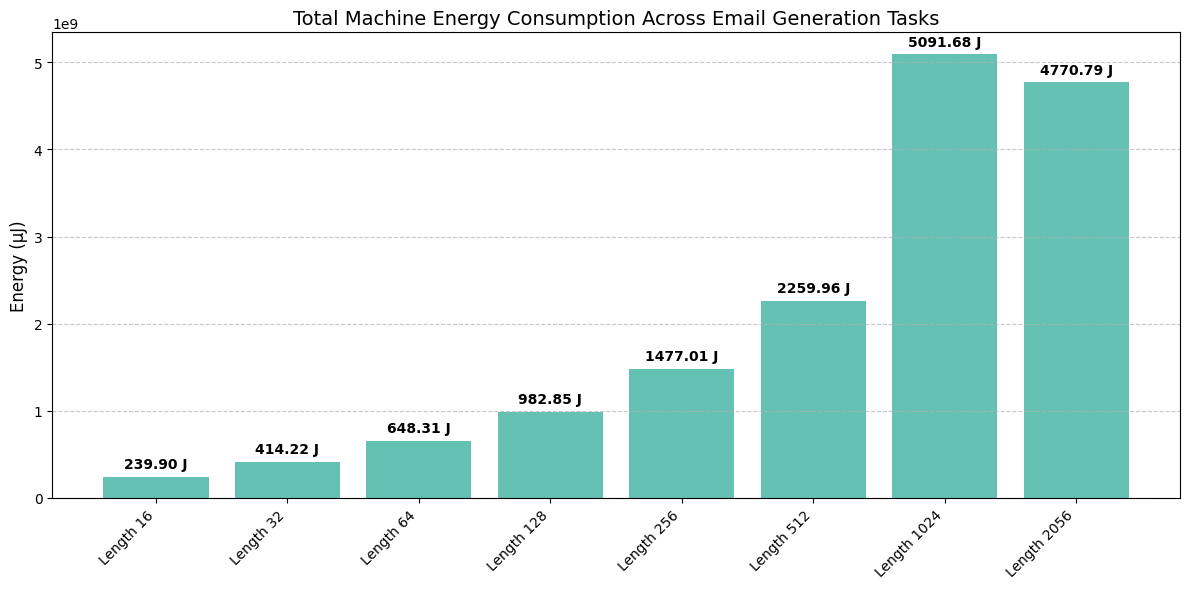

In [390]:

# Extract Total machine energy data from the combined dataframe
mcp_machine_energy_row = combined_df[combined_df['Name'] == selected_measurement]

if not mcp_machine_energy_row.empty:
    # Extract phase names and values
    phases = [col for col in mcp_machine_energy_row.columns if col != 'Name']
    
    # Extract numeric values (removing the unit part)
    values = []
    for phase in phases:
        value_str = mcp_machine_energy_row[phase].values[0]
        # Use regex to extract the numeric part
        numeric_value = float(re.search(r'(\d+)', value_str).group(1))
        values.append(numeric_value)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(phases)), values, color='#65C1B3')
    
    # Add value labels on top of each bar
    for i, (bar, value) in enumerate(zip(bars, values)):
        plt.text(
            i,
            value + 0.02 * max(values),
            f'{value/1e6:.2f} J',
            ha='center',
            fontweight='bold'
        )
    
    # Use shortened phase names for readability - fix the f-string syntax
    short_labels = []
    for phase in phases:
        match = re.search(r'(\d+) words', phase)
        if match:
            short_labels.append(f"Length {match.group(1)}")
        else:
            short_labels.append(phase[:10] + "...")
    
    plt.xticks(range(len(phases)), short_labels, rotation=45, ha='right')
    
    plt.title('Total Machine Energy Consumption Across Email Generation Tasks', fontsize=14)
    plt.ylabel('Energy (μJ)', fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Machine energy data not found in the dataframe")

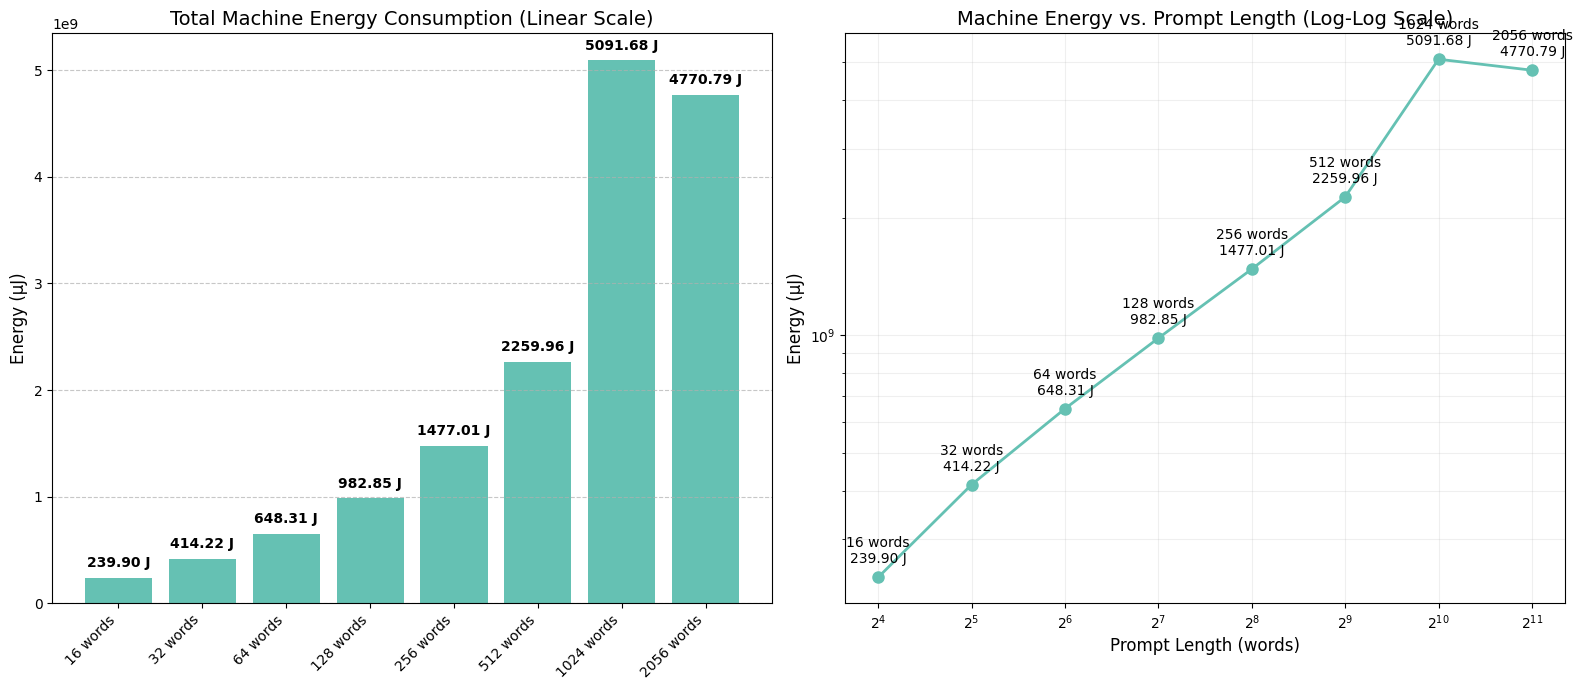

In [391]:

# Extract CPU energy data from the combined dataframe
cpu_energy_row = combined_df[combined_df['Name'] == selected_measurement]

if not cpu_energy_row.empty:
    # Extract phase names and values
    phases = [col for col in cpu_energy_row.columns if col != 'Name']
    
    # Extract numeric values for energy and prompt lengths
    energy_values = []
    prompt_lengths = []
    
    for phase in phases:
        # Extract energy value
        value_str = cpu_energy_row[phase].values[0]
        numeric_value = float(re.search(r'(\d+)', value_str).group(1))
        energy_values.append(numeric_value)
        
        # Extract prompt length from phase name
        match = re.search(r'(\d+) words', phase)
        if match:
            prompt_lengths.append(int(match.group(1)))
        else:
            prompt_lengths.append(0)  # Default if no match
    
    # Sort data by prompt length
    sorted_indices = np.argsort(prompt_lengths)
    sorted_lengths = [prompt_lengths[i] for i in sorted_indices]
    sorted_energy = [energy_values[i] for i in sorted_indices]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Linear scale plot
    bars = ax1.bar(range(len(sorted_lengths)), sorted_energy, color='#65C1B3')
    ax1.set_title('Total Machine Energy Consumption (Linear Scale)', fontsize=14)
    ax1.set_ylabel('Energy (μJ)', fontsize=12)
    ax1.set_xticks(range(len(sorted_lengths)))
    ax1.set_xticklabels([f"{length} words" for length in sorted_lengths], rotation=45, ha='right')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on linear plot
    for i, value in enumerate(sorted_energy):
        ax1.text(
            i, 
            value + 0.02 * max(sorted_energy),
            f'{value/1e6:.2f} J',
            ha='center',
            fontweight='bold'
        )
    
    # Log-log scale plot (more appropriate for doubling values)
    ax2.plot(sorted_lengths, sorted_energy, 'o-', linewidth=2, markersize=8, color='#65C1B3')
    ax2.set_xscale('log', base=2)  # Log scale with base 2 for x-axis
    ax2.set_yscale('log')  # Log scale for y-axis
    ax2.set_title('Machine Energy vs. Prompt Length (Log-Log Scale)', fontsize=14)
    ax2.set_xlabel('Prompt Length (words)', fontsize=12)
    ax2.set_ylabel('Energy (μJ)', fontsize=12)
    ax2.grid(True, which="both", ls="-", alpha=0.2)
    
    # Add value annotations to log plot
    for i, (x, y) in enumerate(zip(sorted_lengths, sorted_energy)):
        ax2.annotate(
            f"{x} words\n{y/1e6:.2f} J", 
            (x, y),
            textcoords="offset points",
            xytext=(0,10), 
            ha='center'
        )
    
    plt.tight_layout()
    plt.show()
    
else:
    print("CPU energy data not found in the dataframe")